In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import gridspec
import pandas as pd
from scipy import special
import os
from scipy.optimize import curve_fit

## Plot H/D/T diffusivity in Li2O

D_0 for H in Katsuta1983 = [6.6529287e-14], std: [1.27236985e-16]
D_0 for D in Katsuta1983 = [1.08163704e-13], std: [3.12740686e-16]
D_0, Q for D in Donato1998 = 1.6353363583721314e-06, 90866.02676123039, std: [3.13599568e-03 2.32534022e+03]


/var/folders/j2/9trt012x7fsfgplsbs9nf22r497b38/T/ipykernel_63786/3783693254.py:130: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("top", functions=(lambda x: 1/x*1000, lambda x: 1000/x))


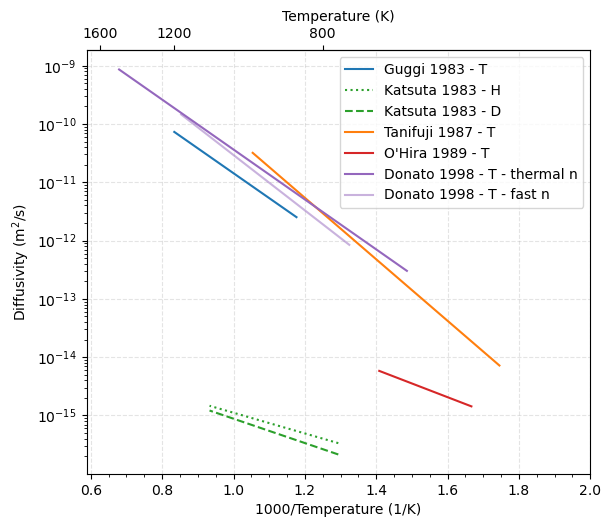

In [34]:
# Diffusivity

def diffusivity_plot(D_0, E, T):
  """_summary_

  Args:
      D_0 (float): pre-factor m^2/s
      E (float): activation energy J/mol
      T (float): Temperature K

  Returns:
      float: diffusivity
  """
  R = 8.3144598 # J⋅mol^−1⋅K^−1
  return D_0 * np.exp(-E/R/T)

def diffusion_fitting(T_inv_data, diff_data, known_parameter = None, known_value = None):
  R = 8.3144598 # J⋅mol^−1⋅K^−1
  if known_parameter == "D_0":
    D_0 = known_value
    def diffusivity_fitting_D_0(T, E):
      return D_0 * np.exp(-E/R/T)
    params, covariance = curve_fit(diffusivity_fitting_D_0, 1e3/T_inv_data, diff_data)
  elif known_parameter == "E":
    E = known_value
    def diffusivity_fitting_E(T, D_0):
      return D_0 * np.exp(-E/R/T)
    params, covariance = curve_fit(diffusivity_fitting_E, 1e3/T_inv_data, diff_data)
  elif known_parameter == None:
    def diffusivity_fitting_none(T, D_0, E):
      return D_0 * np.exp(-E/R/T)
    params, covariance = curve_fit(diffusivity_fitting_none, 1e3/T_inv_data, diff_data)

  return params, covariance


fig = plt.figure(figsize=[6.5, 5.5])
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

# From D. Guggi 1983 - Li2O - Tritium - (850 - 1200 K)
# ln(D cm^2/s) = - (5.93 +- 0.48) - (81.73 +- 4.24) 10^3 J/RT
D_0 = np.exp(-5.93) * 1e-4 # m^2/s
E = 81.73 * 1e3 # J/mol
T_min = 850 # K
T_max = 1200 # K
T_range_Guggi = np.arange(T_min, T_max, 1)
D_range_Guggi = diffusivity_plot(D_0, E,  T_range_Guggi)
ax.plot(1000/T_range_Guggi, D_range_Guggi, label=r"Guggi 1983 - T", c='C0', linestyle='-')

# From Katsuta 1983 - Li2O - H and D - (773 - 1073 K)
# H: 34 kJ/mol
T_inv_data_for_H_Katsuta = np.array([0.9340184387976685, 0.9671873214217684, 0.9976151472437045, 1.0312811916644444, 1.0610689931044992, 1.1045449350451446, 1.1469617890205341, 1.182721246523677])
Diff_data_for_H_Katsuta = np.array([1.455908676454577e-15, 1.2806029334252114e-15, 1.122166727716299e-15, 9.739867851552601e-16, 8.664545979422195e-16, 7.31626689703023e-16, 6.137650330013881e-16, 5.358437653290616e-16])
known_parameter = "E"
known_value = 34e3 # kJ/mol
params, covariance = diffusion_fitting(T_inv_data_for_H_Katsuta, Diff_data_for_H_Katsuta, known_parameter, known_value)
D_0 = params
print(f"D_0 for H in Katsuta1983 = {D_0}, std: {np.sqrt(np.diag(covariance))}")
E = 34 * 1e3 # J/mol
T_min = 773 # K
T_max = 1073 # K
T_range_Katsuta = np.arange(T_min, T_max, 1)
D_range_Katsuta = diffusivity_plot(D_0, E,  T_range_Katsuta)
ax.plot(1000/T_range_Katsuta, D_range_Katsuta, label=r"Katsuta 1983 - H", c='C2', linestyle='dotted')

# D: 40 kJ/mol
T_inv_data_for_D_Katsuta = np.array([0.9417177797249419,0.9676292430187816,1.0002209607985066,1.0428092498761858,1.0816526343860717,1.121071278905863,1.1538953864909138,1.193266410148958])
Diff_data_for_D_Katsuta = np.array([1.1565712506854402e-15,1.0294249494298979e-15,8.7532330267862985e-16,7.223024804730997e-16,5.976094776715709e-16,4.965902216226664e-16,4.252535477937532e-16,3.5630747145594646e-16])
known_parameter = "E"
known_value = 40e3 # kJ/mol
params, covariance = diffusion_fitting(T_inv_data_for_D_Katsuta, Diff_data_for_D_Katsuta, known_parameter, known_value)
D_0 = params
print(f"D_0 for D in Katsuta1983 = {D_0}, std: {np.sqrt(np.diag(covariance))}")
E = 40 * 1e3 # J/mol
T_min = 773 # K
T_max = 1073 # K
T_range_Katsuta = np.arange(T_min, T_max, 1)
D_range_Katsuta = diffusivity_plot(D_0, E,  T_range_Katsuta)
ax.plot(1000/T_range_Katsuta, D_range_Katsuta, label=r"Katsuta 1983 - D", c='C2', linestyle='--')

# From TANIFUJI 1987 - Li2O - Tritium - (573 - 950 K)
# D cm^2/s = 0.116 exp(-(101 +- 2) 10^3 J/RT)
D_0 = 0.116 * 1e-4 # m^2/s
E = 101 * 1e3 # J/mol
T_min = 573 # K
T_max = 950 # K
T_range_Tanifuji = np.arange(T_min, T_max, 1)
D_range_Tanifuji = diffusivity_plot(D_0, E,  T_range_Tanifuji)
ax.plot(1000/T_range_Tanifuji, D_range_Tanifuji, label=r"Tanifuji 1987 - T", c='C1', linestyle='-')

# From O'Hira 1989 - Li2O - T - (600 - 711 K)
# D = 1.21e-7 exp(-(45.1 +- 3.8) 10^3 J/mol /RT ) cm^2/s
D_0 = 1.21e-7 * 1e-4 # m^2/s
E = 45.1 * 1e3 # J/mol
T_min = 600 # K
T_max = 711 # K
T_range_OHira = np.arange(T_min, T_max, 1)
D_range_OHira = diffusivity_plot(D_0, E,  T_range_OHira)
ax.plot(1000/T_range_OHira, D_range_OHira, label=r"O'Hira 1989 - T", c='C3', linestyle='-')

# From Donato 1998 - Li2O - T after irradiation - (673 - 1473 K)
# D = 7e-3 exp(-82 10^3 J/mol /RT ) cm^2/s
D_0 = 7e-3 * 1e-4 # m^2/s
E = 82 * 1e3 # J/mol
T_min = 673 # K
T_max = 1473 # K
T_range_Donato = np.arange(T_min, T_max, 1)
D_range_Donato = diffusivity_plot(D_0, E,  T_range_Donato)
ax.plot(1000/T_range_Donato, D_range_Donato, label=r"Donato 1998 - T - thermal n", c='C4', linestyle='-')
# fast neutron (755 - 1055 K)
T_inv_data_for_T_Donato = np.array([0.6837334987681863,1.486643322854467,0.9479977809459612,0.9892113410363936,1.0218529101223461,1.0657687053728546,1.0982671096821144,1.1379118224279554,1.1695929944702605,1.2119638031722928,1.26161811988857,1.2871074153389128,1.3231670434684053])
Diff_data_for_T_Donato = np.array([0.00000929679407690443,2.043822364218234e-9,6.460103637552051e-7,3.019039678976025e-7,1.6266195709925038e-7,7.041432546675699e-8,3.7949278722903135e-8,1.8361758625556455e-8,1.0377541983586712e-8,4.557159899619529e-9,1.7331564605237827e-9,1.0666752293364485e-9,5.461446658912602e-10])
params, covariance = diffusion_fitting(T_inv_data_for_T_Donato, Diff_data_for_T_Donato)
D_0, E = params
D_0 = D_0 * 1e-4
print(f"D_0, Q for D in Donato1998 = {D_0}, {E}, std: {np.sqrt(np.diag(covariance))}")
T_min = 755 # K
T_max = 1173 # K
T_range_Donato = np.arange(T_min, T_max, 1)
D_range_Donato = diffusivity_plot(D_0, E,  T_range_Donato)
ax.plot(1000/T_range_Donato, D_range_Donato, label=r"Donato 1998 - T - fast n", c='C4', linestyle='-',alpha = 0.5)

# plotting settings
ax.set_xlabel(u'1000/Temperature (1/K)')
ax.set_ylabel(r"Diffusivity (m$^2$/s)")
ax.set_xlim([1000/1700, 1000/500]) # 1/K
ax.set_yscale("log")
ax.legend(loc="best")
ax2 = ax.secondary_xaxis("top", functions=(lambda x: 1/x*1000, lambda x: 1000/x))
ax2.set_xlabel(u'Temperature (K)')
ax2.set_xticks([1600, 1200, 800, 400])
ax2.set_xticklabels([1600, 1200, 800, 400])
plt.grid(visible=True, which='major', color='0.65', linestyle='--', alpha=0.3)
ax.minorticks_on()
plt.savefig('../python_figures/Li2O_diffusivity_summary.png', bbox_inches='tight', dpi=300)
# plt.close(fig)




## Plot solubility in Li2O

S_0 for H in Katsuta1983 = [2.52673439e-06], std: [8.33647009e-09]
S_0 for D in Katsuta1983 = [3.25714715e-06], std: [1.88808859e-08]
S_0 for T in Kudo1991 at 0.3 kPa = [2.0568216e-05], std: [2.04799325e-07]
S_0 for T in Kudo1991 at 67 kPa = [1.63588332e-05], std: [5.47784139e-08]


/var/folders/j2/9trt012x7fsfgplsbs9nf22r497b38/T/ipykernel_63786/424986456.py:163: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("top", functions=(lambda x: 1/x*1000, lambda x: 1000/x))


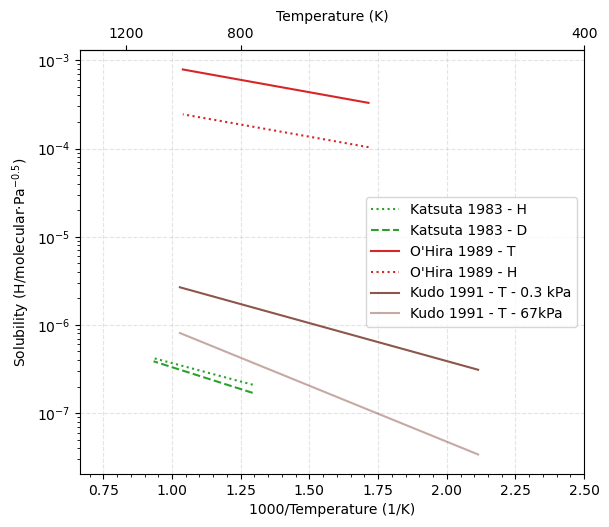

In [36]:

def solubility_plot(S_0, Q, T, P):
  """Plot solubility

  Args:
      S_0 (float): pre-factor H/molecular*Pa^0.5
      Q (float): activation energy J/mol
      T (float): temperature K
      P (float): pressure Pa

  Returns:
      float: solubility
  """
  R = 8.3144598 # J⋅mol^−1⋅K^−1
  alpha = 0.5
  return S_0 * np.exp(-Q/R/T) * P**alpha

def sievert_solubility_plot(S_0, Q, T):
  """Plot sievert solubility

  Args:
      S_0 (float): pre-factor H/molecular*Pa^0.5
      Q (float): activation energy J/mol
      T (float): temperature K

  Returns:
      float: sievert solubility
  """
  R = 8.3144598 # J⋅mol^−1⋅K^−1
  return S_0 * np.exp(-Q/R/T)

def solubility_fitting(T_inv_data, solubility_data, P, known_parameter = None, known_value = None, alpha = 0.5):
  R = 8.3144598 # J⋅mol^−1⋅K^−1
  if known_parameter == "S_0":
    S_0 = known_value
    def solubility_fitting_S_0(T, Q):
      return S_0 * np.exp(-Q/R/T) * P**alpha
    params, covariance = curve_fit(solubility_fitting_S_0, 1e3/T_inv_data, solubility_data)
  elif known_parameter == "Q":
    Q = known_value
    def solubility_fitting_Q(T, S_0):
      return S_0 * np.exp(-Q/R/T) * P**alpha
    params, covariance = curve_fit(solubility_fitting_Q, 1e3/T_inv_data, solubility_data)
  elif known_parameter == None:
    def solubility_fitting_none(T, S_0, Q):
      return S_0 * np.exp(-Q/R/T) * P**alpha
    params, covariance = curve_fit(solubility_fitting_none, 1e3/T_inv_data, solubility_data)

  return params, covariance

# Solubility
fig = plt.figure(figsize=[6.5, 5.5])
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

# From Katsuta 1983 - Li2O - H and D - (773 - 1073 K) - (10 - 100 kPa)
# H: 16 kJ/mol
T_inv_data_for_H_Katsuta = np.array([1.0450211026998057,1.0720606953842031,1.1037870972064046,1.1366369665706437,1.1815173846050782,1.2207462986534467,1.2846573323507737])
Solubility_data_for_H_Katsuta = np.array([0.00006460573731458429,0.00006101851303688574,0.000057722288080389425,0.00005398701162234827,0.00004904708965739401,0.00004529937682495584,0.00003968210662798663])
known_parameter = "Q"
known_value = 16 * 1e3
P = 36 * 1e3 # Pa
params, covariance = solubility_fitting(T_inv_data_for_H_Katsuta, Solubility_data_for_H_Katsuta, P, known_parameter, known_value)
S_0 = params
print(f"S_0 for H in Katsuta1983 = {S_0}, std: {np.sqrt(np.diag(covariance))}")
Q = 16 * 1e3 # J/mol
T_min = 773 # K
T_max = 1073 # K
P = 36 * 1e3 # Pa
T_range_Katsuta = np.arange(T_min, T_max, 1)
# S_range_Katsuta = solubility_plot(S_0, Q, T_range_Katsuta, P)
S_range_Katsuta = sievert_solubility_plot(S_0, Q, T_range_Katsuta)
ax.plot(1000/T_range_Katsuta, S_range_Katsuta, label=r"Katsuta 1983 - H", c='C2', linestyle='dotted')

# D: 19 kJ/mol
T_inv_data_for_D_Katsuta = np.array([1.0434876398472566,1.0816553895625376,1.1261278220673947,1.1763582769478127,1.2385208012326656,1.2802197360487706])
Solubility_data_for_D_Katsuta = np.array([0.0000576731572978842,0.000052425051077603085,0.00004740639135658224,0.00004168033329017693,0.00003592054845758399,0.000032150459807765236])
known_parameter = "Q"
known_value = 19 * 1e3
P = 36 * 1e3 # Pa
params, covariance = solubility_fitting(T_inv_data_for_D_Katsuta, Solubility_data_for_D_Katsuta, P, known_parameter, known_value)
S_0 = params
print(f"S_0 for D in Katsuta1983 = {S_0}, std: {np.sqrt(np.diag(covariance))}")
Q = 19 * 1e3 # J/mol
T_min = 773 # K
T_max = 1073 # K
P = 36 * 1e3 # Pa
T_range_Katsuta = np.arange(T_min, T_max, 1)
# S_range_Katsuta = solubility_plot(S_0, Q, T_range_Katsuta, P)
S_range_Katsuta = sievert_solubility_plot(S_0, Q, T_range_Katsuta)
ax.plot(1000/T_range_Katsuta, S_range_Katsuta, label=r"Katsuta 1983 - D", c='C2', linestyle='--')

# From O'Hira 1989 - Li2O - T - (873 K/ 583-963 K) - (0.03 - 1.3 kPa)
# slope 0.45 +- 0.01 . log Ks = (1290 +- 81) / T + (1.14 +- 0.11) atm^0.5 . Ks = P^0.5 / S
R = 8.3144598 # J⋅mol^−1⋅K^−1
P = 1.3 * 1e3 # Pa
S_0 = np.exp(-1.14) * 101325**(-0.5) # atm^-0.5
Q = 1290 * R # J/mol
T_min = 583 # K
T_max = 963 # K
T_range_OHira = np.arange(T_min, T_max, 1)
# S_range_OHira = solubility_plot(S_0, Q, T_range_OHira, P)
S_range_OHira = sievert_solubility_plot(S_0, Q, T_range_OHira) # S_range_OHira is in X_T
S_range_OHira = 3 * S_range_OHira / (1 - S_range_OHira) # convert from X_T to T/molecular
ax.plot(1000/T_range_OHira, S_range_OHira, label=r"O'Hira 1989 - T", c='C3', linestyle='-')
# - H (From T) - (476 - 596 K) - (1 - 67 kPa)
# log Ks = (1271 +- 46) / T + (2.33 +- 0.07) atm^0.5 . Ks = P^0.5 / S
P = 37 * 1e3 # Pa
S_0 = np.exp(-2.33) * 101325**(-0.5) # atm^-0.5
Q = 1271 * R # J/mol
T_min = 583 # K
T_max = 963 # K
T_range_OHira = np.arange(T_min, T_max, 1)
# S_range_OHira = solubility_plot(S_0, Q, T_range_OHira, P)
S_range_OHira = sievert_solubility_plot(S_0, Q, T_range_OHira) # S_range_OHira is in X_T
S_range_OHira = 3 * S_range_OHira / (1 - S_range_OHira) # convert from X_T to T/molecular
ax.plot(1000/T_range_OHira, S_range_OHira, label=r"O'Hira 1989 - H", c='C3', linestyle='dotted')


# From Kudo 1991 - Li2O - T - (876 K/ 473-973K) - (0.02 - 70 kPa) single crystal and power
# S_H = 7.1 P^0.5 exp(-2000/T), mppm (crystal?)
# S_H = 118.5 exp( - 21.4(kJ/mol)/RT) P^0.5 mppm (power?)
T_inv_data_for_T_Kudo = np.array([0.9724920552638103,1.1419797606436926,1.315693389528725,1.460445355991796,1.587617480673443,1.7765782415650566,1.9479704298045932,2.145428114223895])
Solubility_data_for_T_Kudo = np.array([0.000050735996011860256,0.000036891123559030245,0.000026615383248781572,0.000020204411543654337,0.00001602679530085466,0.000011329461104640206,0.000008213928246031391,0.000005744292153433733])
known_parameter = "Q"
known_value = 16.5 * 1e3
P = 0.3 * 1e3 # Pa
params, covariance = solubility_fitting(T_inv_data_for_T_Kudo, Solubility_data_for_T_Kudo, P, known_parameter, known_value)
S_0 = params
print(f"S_0 for T in Kudo1991 at 0.3 kPa = {S_0}, std: {np.sqrt(np.diag(covariance))}")
Q = 16.5 * 1e3 # J/mol
T_min = 473 # K
T_max = 973 # K
P = 0.3 * 1e3 # Pa
T_range_Kudo = np.arange(T_min, T_max, 1)
# S_range_Kudo = solubility_plot(S_0, Q, T_range_Kudo, P)
S_range_Kudo = sievert_solubility_plot(S_0, Q, T_range_Kudo)
ax.plot(1000/T_range_Kudo, S_range_Kudo, label=r"Kudo 1991 - T - 0.3 kPa", c='C5', linestyle='-')

T_inv_data_for_T_Kudo = np.array([0.9768982848385134,1.065417295859722,1.202066758322252,1.3880073925488516,1.5597151164101062,1.7313439563659312,1.893326421600667,2.0270797178210014,2.163098109040096])
Solubility_data_for_T_Kudo = np.array([0.00024468197193883113,0.00018850633148115214,0.0001258569513472755,0.00007139376712530879,0.000042929942019141005,0.000025564352708113903,0.000015678126351157118,0.00001052210521160051,0.000007011990335194712])
known_parameter = "Q"
known_value = 24.3 * 1e3
P = 67 * 1e3 # Pa
params, covariance = solubility_fitting(T_inv_data_for_T_Kudo, Solubility_data_for_T_Kudo, P, known_parameter, known_value)
S_0 = params
print(f"S_0 for T in Kudo1991 at 67 kPa = {S_0}, std: {np.sqrt(np.diag(covariance))}")
Q = 24.3 * 1e3 # J/mol
T_min = 473 # K
T_max = 973 # K
P = 67 * 1e3 # Pa
T_range_Kudo = np.arange(T_min, T_max, 1)
# S_range_Kudo = solubility_plot(S_0, Q, T_range_Kudo, P)
S_range_Kudo = sievert_solubility_plot(S_0, Q, T_range_Kudo)
ax.plot(1000/T_range_Kudo, S_range_Kudo, label=r"Kudo 1991 - T - 67kPa", c='C5', linestyle='-',alpha=0.5)


# plotting settings
ax.set_xlabel(u'1000/Temperature (1/K)')
ax.set_ylabel(r"Solubility (H/molecular$\cdot$Pa$^{-0.5}$)")
ax.set_xlim([1000/1500, 1000/400]) # 1/K
ax.set_yscale("log")
ax.legend(loc="best")
ax2 = ax.secondary_xaxis("top", functions=(lambda x: 1/x*1000, lambda x: 1000/x))
ax2.set_xlabel(u'Temperature (K)')
ax2.set_xticks([1600, 1200, 800, 400])
ax2.set_xticklabels([1600, 1200, 800, 400])
plt.grid(visible=True, which='major', color='0.65', linestyle='--', alpha=0.3)
ax.minorticks_on()
plt.savefig('../python_figures/Li2O_solubility_summary.png', bbox_inches='tight', dpi=300)
# plt.close(fig)

## Plot H/D/T diffusivity in Fe

/var/folders/j2/9trt012x7fsfgplsbs9nf22r497b38/T/ipykernel_63786/1099968251.py:77: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("top", functions=(lambda x: 1/x*1000, lambda x: 1000/x))
/var/folders/j2/9trt012x7fsfgplsbs9nf22r497b38/T/ipykernel_63786/1099968251.py:145: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("top", functions=(lambda x: 1/x*1000, lambda x: 1000/x))
/var/folders/j2/9trt012x7fsfgplsbs9nf22r497b38/T/ipykernel_63786/1099968251.py:77: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("top", functions=(lambda x: 1/x*1000, lambda x: 1000/x))


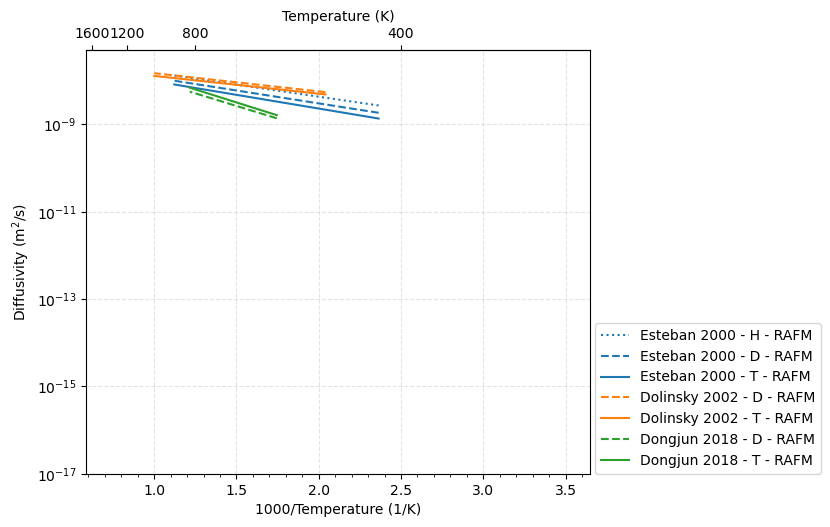

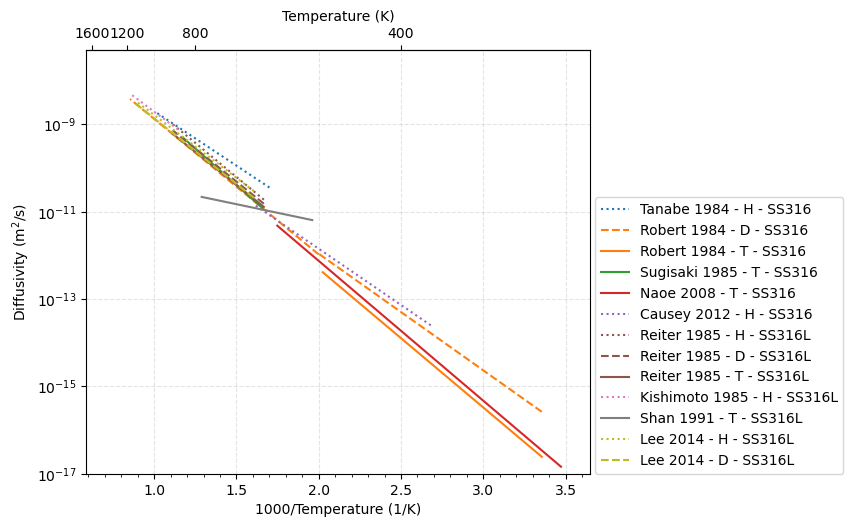

In [29]:
# Diffusivity
# From Sharpe 2016, O'Neal 2022, Urrestizala 2023 summarize the Diffusivity and solubility data

fig = plt.figure(figsize=[6.5, 5.5])
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

# From Esteban 2000 - Fe - H and D - (423 - 892 K) - (4e4 - 1e5 Pa)
# H: D (m^2/s) = 5.489e-8 exp(-10574/RT)
D_0 = 5.489e-8 # m^2/s
E = 10574 # J/mol
T_min = 423 # K
T_max = 892 # K
T_range_Esteban = np.arange(T_min, T_max, 1)
D_range_Esteban = diffusivity_plot(D_0, E,  T_range_Esteban)
ax.plot(1000/T_range_Esteban, D_range_Esteban, label=r"Esteban 2000 - H - RAFM", c='C0', linestyle='dotted')
# D: D (m^2/s) = 4.613e-8 exp(-11321/RT)
D_0 = 4.613e-8 # m^2/s
E = 11321 # J/mol
T_min = 423 # K
T_max = 892 # K
T_range_Esteban = np.arange(T_min, T_max, 1)
D_range_Esteban = diffusivity_plot(D_0, E,  T_range_Esteban)
ax.plot(1000/T_range_Esteban, D_range_Esteban, label=r"Esteban 2000 - D - RAFM", c='C0', linestyle='--')
# T (from H and D) - D (m^2/s) = 4.166e-8 exp(-12027/RT)
D_0 = 4.166e-8 # m^2/s
E = 12027 # J/mol
T_min = 423 # K
T_max = 892 # K
T_range_Esteban = np.arange(T_min, T_max, 1)
D_range_Esteban = diffusivity_plot(D_0, E,  T_range_Esteban)
ax.plot(1000/T_range_Esteban, D_range_Esteban, label=r"Esteban 2000 - T - RAFM", c='C0', linestyle='-')

# From Dolinsky 2002 - reduced activating martensitic steel - D and T - (490 - 1000 K) - (800 - 5300 Pa) - annealed in D2
# D: D (m^2/s) = 3.9e-8 exp(-8.0e3/RT)
D_0 = 3.9e-8 # m^2/s
E = 8.0e3 # J/mol
T_min = 490 # K
T_max = 1000 # K
T_range_Dolinsky = np.arange(T_min, T_max, 1)
D_range_Dolinsky = diffusivity_plot(D_0, E,  T_range_Dolinsky)
ax.plot(1000/T_range_Dolinsky, D_range_Dolinsky, label=r"Dolinsky 2002 - D - RAFM", c='C1', linestyle='--')
# T: D (m^2/s) = 3.3e-8 exp(-7.8e3/RT)
D_0 = 3.3e-8 # m^2/s
E = 7.8e3 # J/mol
T_min = 490 # K
T_max = 1000 # K
T_range_Dolinsky = np.arange(T_min, T_max, 1)
D_range_Dolinsky = diffusivity_plot(D_0, E,  T_range_Dolinsky)
ax.plot(1000/T_range_Dolinsky, D_range_Dolinsky, label=r"Dolinsky 2002 - T - RAFM", c='C1', linestyle='-')

# From Dongjun 2018 - reduced activating martensitic steel (RAFM) - D and T - (573 - 823 K) - (Pa)
# D: D (m^2/s) = 1.43e-7exp(-22110/(RT))
D_0 = 1.43e-7 # m^2/s
E = 22110 # J/mol
T_min = 573 # K
T_max = 823 # K
T_range_Dongjun = np.arange(T_min, T_max, 1)
D_range_Dongjun = diffusivity_plot(D_0, E,  T_range_Dongjun)
ax.plot(1000/T_range_Dongjun, D_range_Dongjun, label=r"Dongjun 2018 - D - RAFM", c='C2', linestyle='--')
# T (from D): D (m^2/s) = 1.95e-7exp(-22797/(RT))
D_0 = 1.95e-7 # m^2/s
E = 22797 # J/mol
T_min = 573 # K
T_max = 823 # K
T_range_Dongjun = np.arange(T_min, T_max, 1)
D_range_Dongjun = diffusivity_plot(D_0, E,  T_range_Dongjun)
ax.plot(1000/T_range_Dongjun, D_range_Dongjun, label=r"Dongjun 2018 - T - RAFM", c='C2', linestyle='-')

# plotting settings
ax.set_xlabel(u'1000/Temperature (1/K)')
ax.set_ylabel(r"Diffusivity (m$^2$/s)")
ax.set_xlim([1000/1700, 1000/274]) # 1/K
ax.legend(loc=[1.01,0])#"best")
ax.set_yscale("log")
ax.set_ylim([1e-17,5e-8])
ax2 = ax.secondary_xaxis("top", functions=(lambda x: 1/x*1000, lambda x: 1000/x))
ax2.set_xlabel(u'Temperature (K)')
ax2.set_xticks([1600, 1200, 800, 400])
ax2.set_xticklabels([1600, 1200, 800, 400])
plt.grid(visible=True, which='major', color='0.65', linestyle='--', alpha=0.3)
ax.minorticks_on()
plt.savefig('../python_figures/RAFM_diffusivity_summary.png', bbox_inches='tight', dpi=300)
# plt.close(fig)

fig = plt.figure(figsize=[6.5, 5.5])
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

# From O'Neal 2022 - SS 316/316L

# H in SS 316: D (m^2/s) = 6.32e-7exp(-47800/(RT)) from [24: Tanabe 1984] (588 - 1000 K) - (1e3 – 1e5 Pa)
D_0, E, T_min, T_max = 6.32e-7, 47800, 588, 1000 # m^2/s, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), diffusivity_plot(D_0, E,  np.arange(T_min, T_max, 1)), label=r"Tanabe 1984 - H - SS316", c='C0', linestyle='dotted')
# D in SS 316: D (m^2/s) = 2.4e-7exp(-51130.39/(RT)) from [31: Robert 1984] (298 - 500 K)
D_0, E, T_min, T_max = 2.4e-7, 51130.39, 298, 500 # m^2/s, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), diffusivity_plot(D_0, E,  np.arange(T_min, T_max, 1)), label=r"Robert 1984 - D - SS316", c='C1', linestyle='--')
# D in SS 316: D (m^2/s) = 1.7e-6exp(-59427.02/(RT)) from [31: Robert 1984] (500 - 1173 K)
D_0, E, T_min, T_max = 1.7e-6, 59427.02, 500, 1173 # m^2/s, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), diffusivity_plot(D_0, E,  np.arange(T_min, T_max, 1)), c='C1', linestyle='--')
# T in SS 316: D (m^2/s) = 1.1e-6exp(-60777.64/(RT)) from [31: Robert 1984] (298 - 495 K)
D_0, E, T_min, T_max = 1.1e-6, 60777.64, 298, 495 # m^2/s, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), diffusivity_plot(D_0, E,  np.arange(T_min, T_max, 1)), label=r"Robert 1984 - T - SS316", c='C1', linestyle='-')
# T in SS 316: D (m^2/s) = 4.2e-6exp(-63961.23/(RT)) from [36: Sugisaki 1985] (603 - 853 K)
D_0, E, T_min, T_max = 4.2e-6, 63961.23, 603, 853 # m^2/s, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), diffusivity_plot(D_0, E,  np.arange(T_min, T_max, 1)), label=r"Sugisaki 1985 - T - SS316", c='C2', linestyle='-')
# T in SS 316: D (m^2/s) = 1.9e-6exp(-61300/(RT)) from [40: Naoe 2008] (288 - 573 K)
D_0, E, T_min, T_max = 1.9e-6, 61300, 288, 573 # m^2/s, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), diffusivity_plot(D_0, E,  np.arange(T_min, T_max, 1)), label=r"Naoe 2008 - T - SS316", c='C3', linestyle='-')
# H in SS 316: D (m^2/s) = 2.01e-7exp(-49300/(RT)) from [41: Causey 2012] (373 - 623 K)
D_0, E, T_min, T_max = 2.01e-7, 49300, 373, 623 # m^2/s, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), diffusivity_plot(D_0, E,  np.arange(T_min, T_max, 1)), label=r"Causey 2012 - H - SS316", c='C4', linestyle='dotted')


# H in SS 316L: D (m^2/s) = 2.99e-6exp(-59716.44/(RT)) from [34: Reiter 1985] (600 - 900 K) - (1e2 - 1e5 Pa)
D_0, E, T_min, T_max = 2.99e-6, 59716.44, 600, 900 # m^2/s, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), diffusivity_plot(D_0, E,  np.arange(T_min, T_max, 1)), label=r"Reiter 1985 - H - SS316L", c='C5', linestyle='dotted')
# D in SS 316L: D (m^2/s) = 1.74e-6exp(-58076.41/(RT)) from [34: Reiter 1985] (600 - 900 K) - (1e2 - 1e5 Pa)
D_0, E, T_min, T_max = 1.74e-6, 58076.41, 600, 900 # m^2/s, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), diffusivity_plot(D_0, E,  np.arange(T_min, T_max, 1)), label=r"Reiter 1985 - D - SS316L", c='C5', linestyle='--')
# T in SS 316L: D (m^2/s) = 1.41e-6exp(-57883.46/(RT)) from [34: Reiter 1985] (600 - 900 K) - (1e2 - 1e5 Pa)
D_0, E, T_min, T_max = 1.41e-6, 57883.46, 600, 900 # m^2/s, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), diffusivity_plot(D_0, E,  np.arange(T_min, T_max, 1)), label=r"Reiter 1985 - T - SS316L", c='C5', linestyle='-')
# H in SS 316L: D (m^2/s) = 1.30e-6exp(-54024.57/(RT)) from [30: Kishimoto 1985] (873 - 1173 K)
D_0, E, T_min, T_max = 1.30e-6, 54024.57, 873, 1173 # m^2/s, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), diffusivity_plot(D_0, E,  np.arange(T_min, T_max, 1)), label=r"Kishimoto 1985 - H - SS316L", c='C6', linestyle='dotted')
# T in SS 316L: D (m^2/s) = 2.3e-10exp(-15146.17/(RT)) from [35: Shan 1991] (500 - 873 K)
D_0, E, T_min, T_max = 2.28e-10, 15124, 510, 777 # m^2/s, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), diffusivity_plot(D_0, E,  np.arange(T_min, T_max, 1)), label=r"Shan 1991 - T - SS316L", c='C7', linestyle='-')
# H in SS 316L: D (m^2/s) = 1.24e-6exp(-55100/(RT)) from [39: Lee 2014] (623 - 1123 K) - (1e5 Pa)
D_0, E, T_min, T_max = 1.24e-6, 55100, 623, 1123 # m^2/s, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), diffusivity_plot(D_0, E,  np.arange(T_min, T_max, 1)), label=r"Lee 2014 - H - SS316L", c='C8', linestyle='dotted')
# D in SS 316L: D (m^2/s) = 1.38e-6exp(-57500/(RT)) from [39: Lee 2014] (623 - 1123 K) - (1e5 Pa)
D_0, E, T_min, T_max = 1.38e-6, 57500, 623, 1123 # m^2/s, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), diffusivity_plot(D_0, E,  np.arange(T_min, T_max, 1)), label=r"Lee 2014 - D - SS316L", c='C8', linestyle='--')


# plotting settings
ax.set_xlabel(u'1000/Temperature (1/K)')
ax.set_ylabel(r"Diffusivity (m$^2$/s)")
ax.set_xlim([1000/1700, 1000/274]) # 1/K
ax.legend(loc=[1.01,0])#"best")
ax.set_yscale("log")
ax.set_ylim([1e-17,5e-8])
ax2 = ax.secondary_xaxis("top", functions=(lambda x: 1/x*1000, lambda x: 1000/x))
ax2.set_xlabel(u'Temperature (K)')
ax2.set_xticks([1600, 1200, 800, 400])
ax2.set_xticklabels([1600, 1200, 800, 400])
plt.grid(visible=True, which='major', color='0.65', linestyle='--', alpha=0.3)
ax.minorticks_on()
plt.savefig('../python_figures/SS316_diffusivity_summary.png', bbox_inches='tight', dpi=300)
# plt.close(fig)




## Plot solubility in Fe

/var/folders/j2/9trt012x7fsfgplsbs9nf22r497b38/T/ipykernel_63786/3600250263.py:46: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("top", functions=(lambda x: 1/x*1000, lambda x: 1000/x))
/var/folders/j2/9trt012x7fsfgplsbs9nf22r497b38/T/ipykernel_63786/3600250263.py:96: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("top", functions=(lambda x: 1/x*1000, lambda x: 1000/x))
/var/folders/j2/9trt012x7fsfgplsbs9nf22r497b38/T/ipykernel_63786/3600250263.py:46: RuntimeWarning: divide by zero encountered in divide
  ax2 = ax.secondary_xaxis("top", functions=(lambda x: 1/x*1000, lambda x: 1000/x))


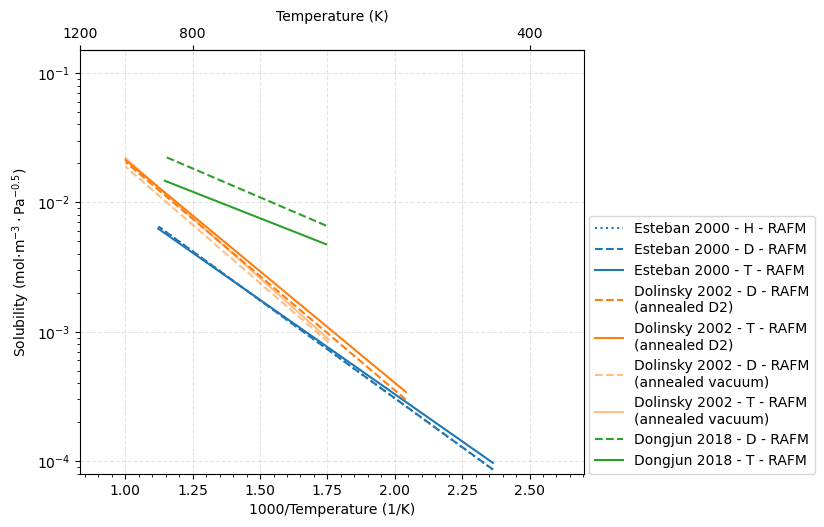

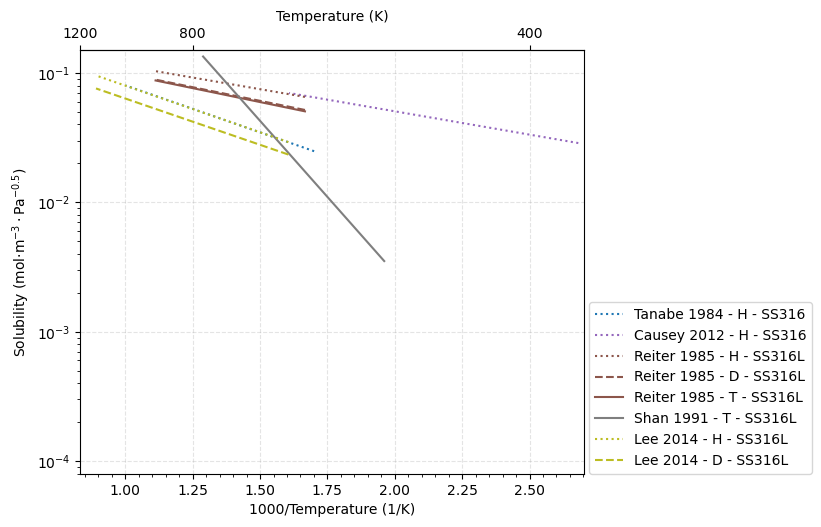

In [33]:

# Solubility
fig = plt.figure(figsize=[6.5, 5.5])
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

# From Esteban 2000 - reduced activating martensitic steel - H and D - (423 - 892 K) - (4e4 - 1e5 Pa)
# H - Ks (mol/m^3/Pa^-0.5) = 0.328 exp(-29005/RT)
# D - Ks (mol/m^3/Pa^-0.5) = 0.325 exp(-28955/RT)
# T (from H and D) - Ks (mol/m^3/Pa^-0.5) = 0.271 exp(-27905/RT)
S_0, Q, T_min, T_max = 0.328, 29005, 423, 892 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=r"Esteban 2000 - H - RAFM", c='C0', linestyle='dotted')
S_0, Q, T_min, T_max = 0.325, 28955, 423, 892 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=r"Esteban 2000 - D - RAFM", c='C0', linestyle='--')
S_0, Q, T_min, T_max = 0.271, 27905, 423, 892 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=r"Esteban 2000 - T - RAFM", c='C0', linestyle='-')

# From Dolinsky 2002 - reduced activating martensitic steel - D and T - (490 - 1000 K) - (800 - 5300 Pa) - annealed in D2
# D: Ks (mol/m^3/Pa^-0.5) = 1.20 exp(-33.8e3/RT)
# T: Ks (mol/m^3/Pa^-0.5) = 1.13 exp(-33.0e3/RT)
# D: Ks (mol/m^3/Pa^-0.5) = 1.20 exp(-34.5e3/RT) annealed in vacuum - (570 - 1000 K)
# T: Ks (mol/m^3/Pa^-0.5) = 1.60 exp(-35.6e3/RT) annealed in vacuum - (570 - 1000 K)
S_0, Q, T_min, T_max = 1.20, 33.8e3, 490, 1000 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=u"Dolinsky 2002 - D - RAFM\n(annealed D2)", c='C1', linestyle='--')
S_0, Q, T_min, T_max = 1.13, 33.0e3, 490, 1000 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=u"Dolinsky 2002 - T - RAFM\n(annealed D2)", c='C1', linestyle='-')
S_0, Q, T_min, T_max = 1.20, 34.5e3, 570, 1000 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=u"Dolinsky 2002 - D - RAFM\n(annealed vacuum)", c='C1', alpha = 0.5, linestyle='--')
S_0, Q, T_min, T_max = 1.60, 35.6e3, 570, 1000 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=u"Dolinsky 2002 - T - RAFM\n(annealed vacuum)", c='C1', alpha = 0.5, linestyle='-')

# From Dongjun 2018 - reduced activating martensitic steel (RAFM) - D and T - (573 - 873 K) - (Pa)
# D: Ks (mol/m^3/Pa^-0.5) = 2.38e-1 exp(-17071/RT)
# T (from D): Ks (mol/m^3/Pa^-0.5) = 1.28e-1 exp(-15696/RT)
S_0, Q, T_min, T_max = 2.38e-1, 17071, 573, 873 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=r"Dongjun 2018 - D - RAFM", c='C2', linestyle='--')
S_0, Q, T_min, T_max = 1.28e-1, 15696, 573, 873 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=r"Dongjun 2018 - T - RAFM", c='C2', linestyle='-')

# plotting settings
ax.set_xlabel(u'1000/Temperature (1/K)')
ax.set_ylabel(r"Solubility (mol$\cdot$m$^{-3}\cdot$Pa$^{-0.5}$)")
ax.set_xlim([1000/1200, 1000/370]) # 1/K
ax.legend(loc=[1.01,0])
ax.set_yscale("log")
ax.set_ylim([0.8e-4,1.5e-1])
ax2 = ax.secondary_xaxis("top", functions=(lambda x: 1/x*1000, lambda x: 1000/x))
ax2.set_xlabel(u'Temperature (K)')
ax2.set_xticks([1600, 1200, 800, 400])
ax2.set_xticklabels([1600, 1200, 800, 400])
plt.grid(visible=True, which='major', color='0.65', linestyle='--', alpha=0.3)
ax.minorticks_on()
plt.savefig('../python_figures/RAFM_solubility_summary.png', bbox_inches='tight', dpi=300)

fig = plt.figure(figsize=[6.5, 5.5])
gs = gridspec.GridSpec(1, 1)
ax = fig.add_subplot(gs[0])

# From O'Neal 2022 - SS 316

# H in SS 316: Ks (mol.m^-3.MPa^-0.5) = 4.27e2exp(-3.9e3/(RT)) from [24: Tanabe 1984] (588 - 1000 K) - (1e3 – 1e5 Pa) mol.m^-3.MPa^-0.5
S_0, Q, T_min, T_max = 4.27e2 * 1e-3, 13.9e3, 588, 1000 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=r"Tanabe 1984 - H - SS316", c='C0', linestyle='dotted')
# H in SS 316: Ks (mol.m^-3.MPa^-0.5) = 266 exp(-6.9e3/(RT)) from [41: Causey 2012] (373 - 623 K) mol.m^-3.MPa^-0.5
S_0, Q, T_min, T_max = 266 * 1e-3, 6.9e3, 373, 623 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=r"Causey 2012 - H - SS316", c='C4', linestyle='dotted')

# From O'Neal 2022 - SS 316L
# [H] Pa^-0.5
# H in SS 316L: Ks (Pa^-0.5) = 1.84e-6exp(-6880/(RT)) from [34: Reiter 1985] (600 - 900 K) - (1e2 - 1e5 Pa)
# shan 1991
S_0, Q, T_min, T_max = 1.84e-6 * 7.874e6 / 55.845, 6880, 600, 900 # mol.m^-3.Pa^-0.5, J/mol, K, K (?????? atom fraction to mol/m3)
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=r"Reiter 1985 - H - SS316L", c='C5', linestyle='dotted')
# D in SS 316L: Ks (Pa^-0.5) = 1.86e-6exp(-8090/(RT)) from [34: Reiter 1985] (600 - 900 K) - (1e2 - 1e5 Pa)
S_0, Q, T_min, T_max = 1.86e-6 * 7.874e6 / 55.845, 8090, 600, 900 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=r"Reiter 1985 - D - SS316L", c='C5', linestyle='--')
# T in SS 316L: Ks (Pa^-0.5) = 1.87e-6exp(-8240/(RT)) from [34: Reiter 1985] (600 - 900 K) - (1e2 - 1e5 Pa)
S_0, Q, T_min, T_max = 1.87e-6 * 7.874e6 / 55.845, 8240, 600, 900 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=r"Reiter 1985 - T - SS316L", c='C5', linestyle='-')
# T in SS 316L: shan 1991
S_0, Q, T_min, T_max = 1.44e5 * 1e-3, 45028, 510, 777 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=r"Shan 1991 - T - SS316L", c='C7', linestyle='-')
# H in SS 316L: Ks (mol.m^-3.Pa^-0.5) = 0.42e(-13.8/(RT)) from [39: Lee 2014] (623 - 1123 K) - (1e5 Pa)
S_0, Q, T_min, T_max = 0.42, 13.8e3, 623, 1123 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=r"Lee 2014 - H - SS316L", c='C8', linestyle='dotted')
# D in SS 316L: Ks (mol.m^-3.Pa^-0.5) = 0.33exp(-13.7/(RT)) from [39: Lee 2014] (623 - 1123 K) - (1e5 Pa)
S_0, Q, T_min, T_max = 0.33, 13.7e3, 623, 1123 # mol.m^-3.Pa^-0.5, J/mol, K, K
ax.plot(1000/np.arange(T_min, T_max, 1), sievert_solubility_plot(S_0, Q, np.arange(T_min, T_max, 1)), label=r"Lee 2014 - D - SS316L", c='C8', linestyle='--')

# plotting settings
ax.set_xlabel(u'1000/Temperature (1/K)')
ax.set_ylabel(r"Solubility (mol$\cdot$m$^{-3}\cdot$Pa$^{-0.5}$)")
ax.set_xlim([1000/1200, 1000/370]) # 1/K
ax.legend(loc=[1.01,0])
ax.set_yscale("log")
ax.set_ylim([0.8e-4,1.5e-1])
ax2 = ax.secondary_xaxis("top", functions=(lambda x: 1/x*1000, lambda x: 1000/x))
ax2.set_xlabel(u'Temperature (K)')
ax2.set_xticks([1600, 1200, 800, 400])
ax2.set_xticklabels([1600, 1200, 800, 400])
plt.grid(visible=True, which='major', color='0.65', linestyle='--', alpha=0.3)
ax.minorticks_on()
plt.savefig('../python_figures/SS316_solubility_summary.png', bbox_inches='tight', dpi=300)
# plt.close(fig)